# StarCoarsener example

This notebook shows the clean encoded-node schema: `label` plus `super_uids`, with tuple-valued `attach_map` on edges.

In [1]:
from tree_coarsening import StarCoarsener, star_token
from tree_coarsening.utils import make_starburst_dataset
import networkx as nx

X = make_starburst_dataset(n_graphs=3, seed=0, max_nodes=200, n_bursts=2, burst_size_range=(20, 25))
coarsener = StarCoarsener(d=3, m=1).fit(X)
H = coarsener.transform(X[0])
print(H.number_of_nodes(), H.number_of_edges())

22 21


In [2]:
for node, data in H.nodes.items():
    print(f'Node: {node} | Attributes: {data}')

Node: 0 | Attributes: {'label': 'base:D', 'time': 0.0, 'uid': 'g0_n0', 'type': 'base:D', 'raw_label': 'D', 'super_label': 'g0_n0', 'super_time': 0.0, 'time_span': (0.0, 0.0)}
Node: 1 | Attributes: {'label': 'base:P', 'time': 1.4389372671069092, 'uid': 'g0_n1', 'type': 'base:P', 'raw_label': 'P', 'super_label': 'g0_n1', 'super_time': 1.4389372671069092, 'time_span': (1.4389372671069092, 1.4389372671069092)}
Node: 2 | Attributes: {'label': 'base:C', 'time': 1.6958828134514088, 'uid': 'g0_n2', 'type': 'base:C', 'raw_label': 'C', 'super_label': 'g0_n2', 'super_time': 1.6958828134514088, 'time_span': (1.6958828134514088, 1.6958828134514088)}
Node: 3 | Attributes: {'label': 'base:P', 'time': 1.1761974559208563, 'uid': 'g0_n3', 'type': 'base:P', 'raw_label': 'P', 'super_label': 'g0_n3', 'super_time': 1.1761974559208563, 'time_span': (1.1761974559208563, 1.1761974559208563)}
Node: 4 | Attributes: {'label': 'base:C', 'time': 2.785729866927309, 'uid': 'g0_n4', 'type': 'base:C', 'raw_label': 'C',

In [3]:
for u, v, data in H.edges(data=True):
    print(f'Edge: {u} -> {v} | Attributes: {data}')

Edge: 0 -> 1 | Attributes: {'attach_map': (0,), 'attach_index': 0}
Edge: 0 -> 2 | Attributes: {'attach_map': (0,), 'attach_index': 0}
Edge: 0 -> 3 | Attributes: {'attach_map': (0,), 'attach_index': 0}
Edge: 1 -> ('__tc_star__', 'StarCoarsener:5fae57b0cc2c456a85213d7786aad6f5', 0) | Attributes: {'attach_map': (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)}
Edge: 2 -> 4 | Attributes: {'attach_map': (0,), 'attach_index': 0}
Edge: 2 -> 5 | Attributes: {'attach_map': (0,), 'attach_index': 0}
Edge: 3 -> ('__tc_star__', 'StarCoarsener:5fae57b0cc2c456a85213d7786aad6f5', 1) | Attributes: {'attach_map': (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)}
Edge: 4 -> 6 | Attributes: {'attach_map': (0,), 'attach_index': 0}
Edge: 4 -> 7 | Attributes: {'attach_map': (0,), 'attach_index': 0}
Edge: 7 -> 8 | Attributes: {'attach_map': (0,), 'attach_index': 0}
Edge: ('__tc_star__', 'StarCoarsener:5fae57b0cc2c456a85213d7786aad6f5', 0) -> 44 | Attributes: {'attach_map': (8,), 'attac

In [4]:
G_roundtrip = coarsener.decode(H)
assert G_roundtrip.number_of_nodes() == X[0].number_of_nodes()
assert G_roundtrip.number_of_edges() == X[0].number_of_edges()
print('roundtrip ok')

roundtrip ok


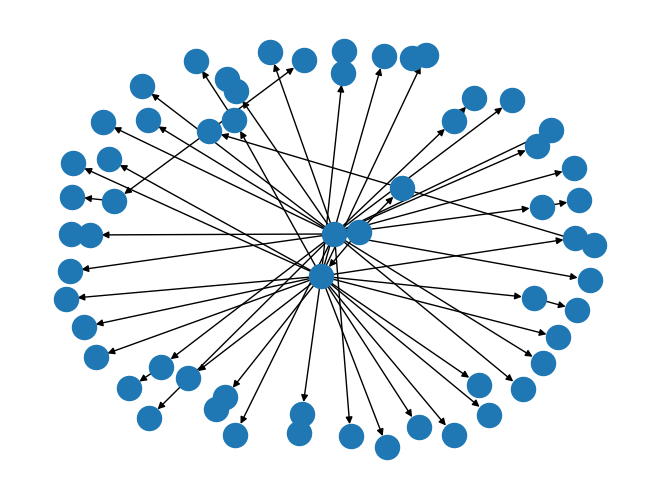

In [5]:
nx.draw(X[0])

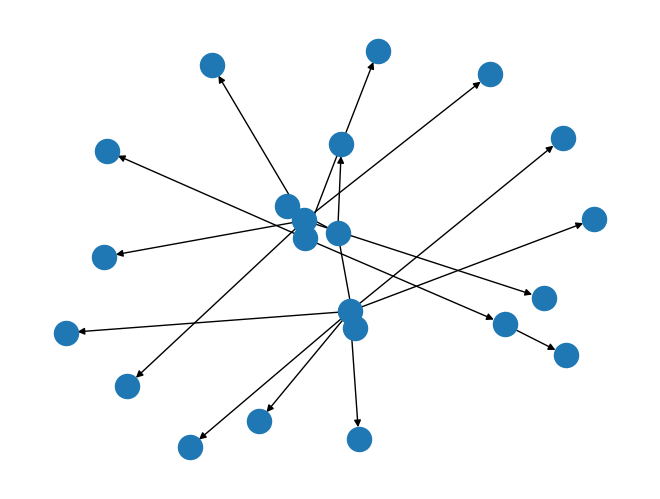

In [6]:
nx.draw(H)